In [4]:
import numpy as np
import pandas as pd
import evaluate
import warnings
import torch
import os
import random
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

warnings.filterwarnings("ignore", category=FutureWarning)
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)


C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# specify encoding to avoid UnicodeDecodeError (common with this dataset)
df = pd.read_csv('spam.csv', encoding='latin-1')
df['label'] = df['v1'].map({'ham': 0, 'spam': 1})
df = df[['v2', 'label']]

In [6]:
df

,v2,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1
5568,Will Ì_ b going to esplanade fr home?,0
5569,"Pity, * was in mood for that. So...any other s...",0
5570,The guy did some bitching but I acted like i'd...,0


In [8]:
#find number of label 1 and label 0
label_counts = df['label'].value_counts()
label_counts

label
0    4825
1     747
Name: count, dtype: int64

EDA

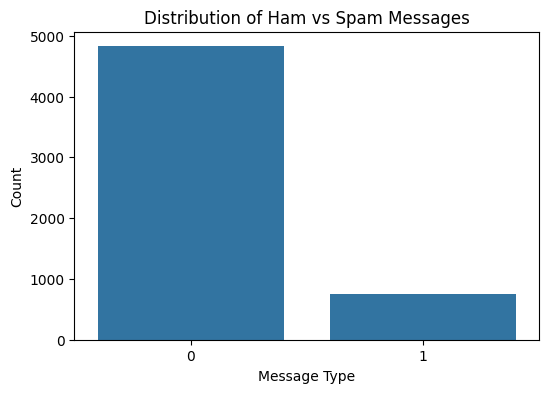

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham vs Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()


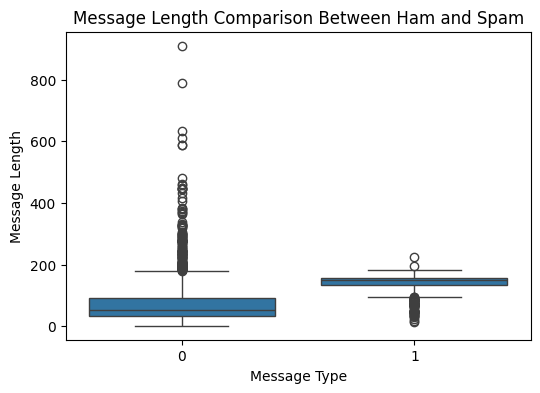

In [10]:
plt.figure(figsize=(6,4))
df['message_length'] = df['v2'].apply(len)
sns.boxplot(x='label', y='message_length', data=df)
plt.title('Message Length Comparison Between Ham and Spam')
plt.xlabel('Message Type')
plt.ylabel('Message Length')
plt.show()


run below 

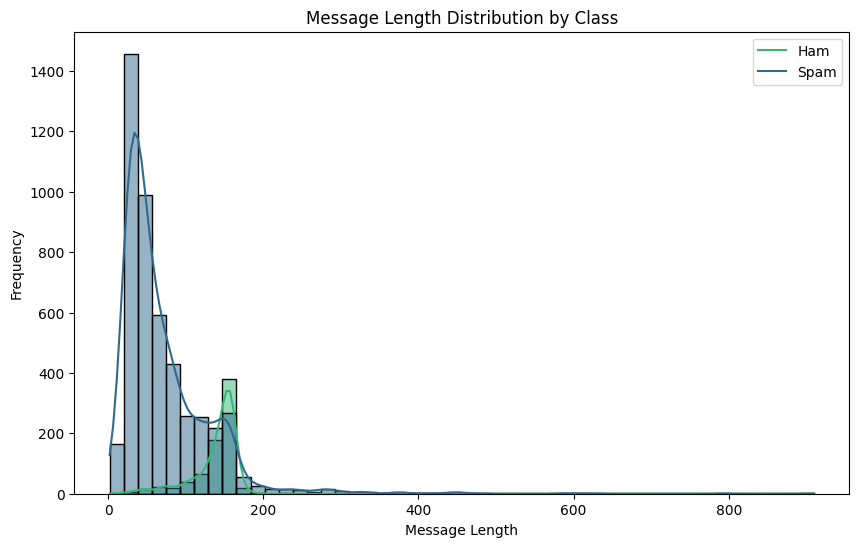

In [5]:
df['message_length'] = df['v2'].apply(len)
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette='viridis')
plt.title('Message Length Distribution by Class')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend(['Ham', 'Spam'])
plt.show()

In [28]:
df['message_length'] = df['v2'].apply(len)
df[['message_length']].describe()

,message_length
count,5572.000000
mean,80.118808
std,59.690841
min,2.000000
25%,36.000000
50%,61.000000
75%,121.000000
max,910.000000


Naive Bayes

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_tfidf = tfidf.fit_transform(df['v2'])
y = df['label']


In [31]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [32]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train_tfidf)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [33]:
from sklearn.metrics import classification_report, accuracy_score

nb_preds = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test_tfidf, nb_preds)
print("Naive Bayes Accuracy:", nb_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_tfidf, nb_preds))


Naive Bayes Accuracy: 0.9739910313901345

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



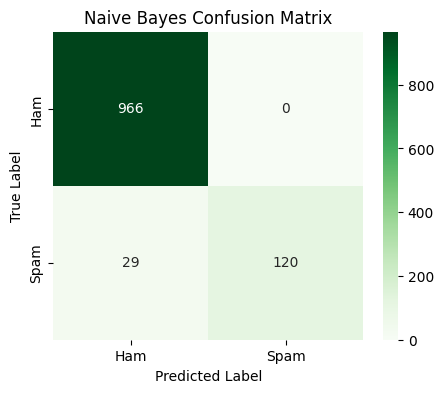

In [34]:
cm_nb = confusion_matrix(y_test_tfidf, nb_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Naive Bayes Confusion Matrix')
plt.show()


***BERT

Train test

In [19]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['v2'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
test_df = pd.DataFrame({'text': test_texts, 'label': test_labels})

Tokenizer and Model initialization

In [18]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Preprocessing

In [21]:
# convert pandas DataFrames to Hugging Face Dataset objects and tokenize in batched mode
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding=True)

train_dataset = train_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

# set torch format for Trainer compatibility
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map: 100%|██████████| 1115/1115 [00:00<00:00, 2464.66 examples/s]


Training Arguments

In [11]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable


In [12]:
!pip install "accelerate>=0.26.0"

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import accelerate
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch", 
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,  
    load_best_model_at_end=True,
    report_to="none", 
)

In [16]:
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(-1)
    return metric.compute(predictions=predictions, references=labels)

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

In [23]:
# Evaluate DistilBERT model
bert_results = trainer.evaluate()

bert_results


C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.6809617877006531,
 'eval_model_preparation_time': 0.01,
 'eval_accuracy': 0.7201793721973094,
 'eval_runtime': 331.2736,
 'eval_samples_per_second': 3.366,
 'eval_steps_per_second': 0.211}

train the model

In [16]:
trainer.train()
eval_results = trainer.evaluate()
print(f"Accuracy: {eval_results['eval_accuracy'] * 100:.2f}%")

C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.025800,0.038952,0.992825
2,0.001300,0.042368,0.992825
3,0.021300,0.042403,0.992825


C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Accuracy: 99.28%


In [19]:
model.save_pretrained("sms_spam_distilbert_model")
tokenizer.save_pretrained("sms_spam_distilbert_model")


('sms_spam_distilbert_model\\tokenizer_config.json',
 'sms_spam_distilbert_model\\special_tokens_map.json',
 'sms_spam_distilbert_model\\vocab.txt',
 'sms_spam_distilbert_model\\added_tokens.json',
 'sms_spam_distilbert_model\\tokenizer.json')

In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


In [25]:
# show columns/features for dataframes and datasets in the notebook
print("df columns:", df.columns.tolist())
print("train_df columns:", train_df.columns.tolist())
print("test_df columns:", test_df.columns.tolist())

# dataset features (if interested)
print("train_dataset features:", list(train_dataset.features.keys()))
print("test_dataset features:", list(test_dataset.features.keys()))

df columns: ['v2', 'label', 'message_length']
train_df columns: ['text', 'label']
test_df columns: ['text', 'label']
train_dataset features: ['text', 'label', 'input_ids', 'attention_mask']
test_dataset features: ['text', 'label', 'input_ids', 'attention_mask']


C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


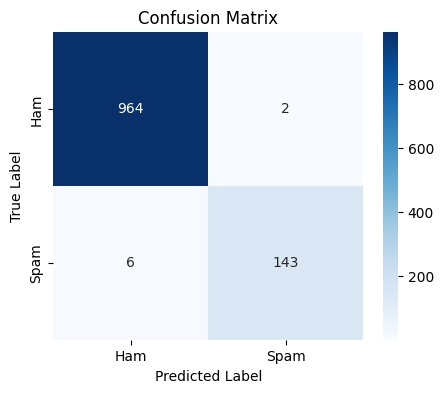

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = trainer.predict(test_dataset)
y_preds = predictions.predictions.argmax(axis=1)
y_test = test_dataset['label']

cm = confusion_matrix(y_test, y_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [27]:
def predict_sms(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    prediction = outputs.logits.argmax(dim=1).item()
    return "Spam" if prediction == 1 else "Ham"

# Example
print(predict_sms("Congratulations! You won a free voucher. Click now!"))


Ham


Comparison Table

In [35]:
comparison_df = pd.DataFrame({
    'Model': ['Naive Bayes (TF-IDF)', 'DistilBERT'],
    'Accuracy': [nb_accuracy, predictions.metrics['test_accuracy']]
})

comparison_df


,Model,Accuracy
0,Naive Bayes (TF-IDF),0.973991
1,DistilBERT,0.992825


In [36]:
predictions.metrics


{'test_loss': 0.03895179554820061,
 'test_accuracy': 0.9928251121076234,
 'test_runtime': 335.8725,
 'test_samples_per_second': 3.32,
 'test_steps_per_second': 0.208}

Testing the model

In [37]:
import torch

model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [38]:
def test_sms(message):
    inputs = tokenizer(
        message,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1).item()

    if prediction == 1:
        return "Spam"
    else:
        return "Ham"


In [39]:
print(test_sms("Congratulations! You have won a free prize. Click now"))
print(test_sms("Hi, are we meeting tomorrow at 10am?"))


Spam
Ham


In [40]:
test_messages = [
    "URGENT! Your account has been suspended. Verify now",
    "Hey, can you send me the notes from class?",
    "Win cash instantly by clicking this link",
    "Your appointment is confirmed for tomorrow"
]

for msg in test_messages:
    print(f"Message: {msg}")
    print(f"Prediction: {test_sms(msg)}\n")


Message: URGENT! Your account has been suspended. Verify now
Prediction: Ham

Message: Hey, can you send me the notes from class?
Prediction: Ham

Message: Win cash instantly by clicking this link
Prediction: Spam

Message: Your appointment is confirmed for tomorrow
Prediction: Ham

